In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt



# Bias Under Pressure: A Structural Analysis of Referee Bias in NBA Close Games

## 1. Abstract

This study examines whether referee errors in NBA close games follow a systematic pattern consistent with known cognitive biases — specifically home court bias driven by crowd pressure, strength bias toward the stronger team, and star player bias toward higher-rated players. The analysis draws on NBA Last Two Minute (L2M) reports covering seasons 2015–2025 [AtlhawksfanaticL2M] as the primary dataset, and pre-game ELO ratings [NeilPaineELO] as an independent second source. The methodology of Pelechrinis (2023) [PelechrinisL2M] is replicated and extended to the Post-COVID period (2023–2025). The COVID-19 pandemic, during which NBA games were played without fans, serves as a natural comparison period within the dataset.

## 2. Introduction  
Prior work has documented several types of referee bias in professional sports. Home court bias is perhaps the most studied — referees tend to favor the home team, and this effect has been linked to crowd noise and social pressure [PelechrinisL2M]. Bias toward stronger and more successful teams has also been reported in football [ErikstadJohansen2020], while evidence for star player bias in the NBA suggests that higher-salaried players draw more favourable calls [Barrett2021].

In this project, I examine whether NBA referee errors in close games show systematic patterns across three dimensions: home court advantage, team strength as measured by pre-game ELO ratings, and individual player quality as measured by Player Efficiency Rating (PER). The analysis uses Last Two Minute reports (2015–2025) [AtlhawksfanaticL2M], which provide ground truth — every referee decision in the final two minutes of close games is graded as correct or incorrect by the NBA league office. The COVID-19 pandemic, during which games were played without fans, serves as a natural comparison period within the dataset.

## 3. Methods

### 3.1 Core Definitions

Following Pelechrinis (2023) [PelechrinisL2M], referee errors are classified by their directional benefit. For each game, incorrect calls (IC) and incorrect non-calls (INC) are classified by which side benefits from the error.

The **whistle benefit** $\beta$ — the number of errors that favor the home team:
$$\beta = |INC : committing\_side = home| + |IC : committing\_side = away|$$

The **whistle detriment** $\delta$ — the number of errors that favor the away team:
$$\delta = |INC : committing\_side = away| + |IC : committing\_side = home|$$

The **Net Whistle Gain** (NWG) for the home team:
$$NWG = \beta - \delta$$

A positive NWG indicates that the home team benefited more from referee errors than expected. This measure is extended with the **Asymmetry Ratio** (AR), which normalizes NWG to a [0,1] scale for cross-group comparison:
$$AR = \frac{\beta}{\beta + \delta}$$

An AR of 0.5 indicates no directional bias. AR > 0.5 indicates bias favoring the home team; AR < 0.5 indicates bias favoring the away team.

### 3.2 Monte Carlo Simulation

To assess statistical significance of NWG, the simulation approach of Pelechrinis (2023) [PelechrinisL2M] is followed. A chi-square test on $\beta$ and $\delta$ would ignore the fact that different violation types have different base rates of being called correctly. To control for this, the expected distribution of NWG is simulated under the null hypothesis of no bias.

For each violation type $v$, two probabilities are estimated from the observed data:
$$p_1^v = \frac{|INC_v|}{|INC_v| + |IC_v| + |CC_v|}$$
$$p_2^v = \frac{|INC_v| + |IC_v|}{|INC_v| + |IC_v| + |CC_v|}$$

For each simulation run, every event in the dataset is assigned a random number $r \sim U(0,1)$. The decision boundaries are:
$$\text{decision} = \begin{cases} IC & \text{if } r < p_1^v \\ INC & \text{if } p_1^v \leq r < p_2^v \\ CC & \text{if } r \geq p_2^v \end{cases}$$

The simulated NWG ($\widehat{NWG}$) is computed for each run. After $n = 10{,}000$ simulations, the empirical p-value is:
$$p = \frac{|\{\widehat{NWG} \geq NWG_{real}\}|}{n}$$

The effect size is reported as:
$$\text{effect} = NWG_{real} - \mathbb{E}[\widehat{NWG}]$$

### 3.3 Research Questions and Hypotheses

**RQ1: Home Court Bias Across Periods**

Home court bias is tested across three periods defined by crowd presence conditions:
- Pre-COVID: seasons 2015–2019
- COVID: seasons 2020–2022
- Post-COVID: seasons 2023–2025

$$H_0^{RQ1}: \text{effect} = 0 \quad \text{(no systematic home bias)}$$
$$H_1^{RQ1}: \text{effect} > 0 \quad \text{(errors favor home team)}$$

Statistical test: Monte Carlo simulation (Section 3.2).
Significance level: $\alpha = 0.05$.

**RQ2: Strength Bias**

Referee errors are tested for systematic bias toward the stronger team, 
defined by pre-game ELO rating difference:
$$elo\_diff = ELO_{home} - ELO_{away}$$

AR is compared between two groups: games where the home team is stronger 
($elo\_diff > 0$) and games where the home team is weaker ($elo\_diff < 0$). 
Additionally, the in-game score difference is examined as a moderating factor:
$$score\_diff = score_{home} - score_{away}$$

$$H_0^{RQ2}: AR_{strong} = AR_{weak} \quad \text{(no strength bias)}$$

Statistical tests: Chi-square test on aggregated $\beta$ and $\delta$ per group; 
two-sample T-test on AR distributions.

**RQ3: Star Player Bias**

Errors are tested for systematic bias toward players with higher career Player Efficiency Rating (PER), used as a proxy for player status and reputation. Players are grouped into terciles by PER:

- Low PER: bottom third
- Medium PER: middle third
- High PER: top third

$$H_0^{RQ3}: AR_{high} = AR_{medium} = AR_{low} \quad \text{(no player bias)}$$

Statistical tests: Chi-square test per group; one-way ANOVA on AR across groups.

### 3.4 Structural Comparison: Kolmogorov-Smirnov Test

The two-sample Kolmogorov-Smirnov test is applied to compare AR distributions across groups. The KS statistic is:

$$D = \sup_x |F_1(x) - F_2(x)|$$

where $F_1$ and $F_2$ are the empirical cumulative distribution functions of two AR distributions. A small $D$ with a large p-value indicates that the two distributions are statistically indistinguishable.

$$H_0^{KS}: F_1 = F_2 \quad \text{(distributions are identical)}$$
$$H_1^{KS}: F_1 \neq F_2 \quad \text{(distributions differ)}$$

KS tests are applied across periods:
- Pre-COVID vs COVID
- Pre-COVID vs Post-COVID
- COVID vs Post-COVID

Additionally, KS tests are applied across the three bias types to examine whether they share a common distributional structure:
- AR of home bias vs AR of strength bias
- AR of home bias vs AR of star player bias
- AR of strength bias vs AR of star player bias

$$H_0^{KS}: F_{home} = F_{strength} = F_{star}$$

### 3.5 Multiple Comparisons

Multiple hypothesis tests are conducted at $\alpha = 0.05$, which increases the risk of false positive results. Some researchers recommend **Bonferroni correction** to address this, but the unadjusted approach of Pelechrinis (2023) [PelechrinisL2M] is followed here. Results should be interpreted with this limitation in mind.

## Part 1: NBA Last Two Minute Reports

The NBA component is the foundation of our cross-domain framework — it provides ground truth validation because every decision is classified as correct or incorrect. We use this to measure home/away bias and team strength bias through error rate asymmetry: the proportion of incorrect decisions (IC and INC) that favor the home team or the stronger team.

For each game we calculate the net whistle gain — the difference between errors favoring home and errors favoring away. We then examine how this measure varies across three dimensions: crowd pressure (ATTENDANCE), competitive context (playoff vs regular season), and time (season). The correlation between attendance and home bias tests the crowd pressure hypothesis directly — if bias decreases when attendance is low, crowd noise is a driver.

Team strength bias is measured by joining the error data with `haberstroh_team_ratings` — we test whether errors systematically favor higher-rated teams regardless of home/away status. Referee quality is controlled for using `haberstroh_ref_ratings` — we check whether games with lower-rated crews show stronger bias.

Variance in net whistle gain across games is the key discriminator. Low variance with a shifted mean suggests all games show the same pattern — coordinated or structural bias. High variance with a shifted mean suggests the bias is inconsistent — driven by individual circumstances and social pressure rather than a systematic mechanism.

Statistical methods: T-test for the attendance effect, ANOVA for differences across seasons, Chi-square for home/away asymmetry, and Logistic Regression to predict the direction of an error from game context.

### 1.1 Dataset

The primary dataset is the NBA Last Two Minute (L2M) reports, maintained by atlhawksfanatic [AtlhawksfanaticL2M]. The reports are released by the NBA for games that were within 5 points in the last two minutes, and cover seasons 2015 through 2025.

The dataset is compiled from two sources: archived PDF reports for earlier seasons and the official NBA API for more recent ones. It is supplemented with box score data from stats.nba.com, which adds referee identities, attendance, and player minutes.

Three additional files from the atlhawksfanatic EDA folder are included:
- `haberstroh_ref_ratings.csv` — referee quality ratings by season
- `haberstroh_team_ratings.csv` — team ratings by season
- `no_minutes.csv` — where `committing_min` is missing due to NBA input errors [AtlhawksfanaticL2M]

The dataset is the primary source used in [PelechrinisL2M] as confirmed by [PelechrinisCode].

#### 1.1.1. Initial Data Analysis (IDA)

In [3]:
l2m = pd.read_csv('data/input/nba/tidy/L2M_stats_nba.csv', low_memory=False)
elo = pd.read_csv('data/input/nba/nba_elo.csv', low_memory=False)
tv  = pd.read_csv('data/input/nba/eda/haberstroh_team_ratings.csv', low_memory=False)

In [4]:
l2m['playoff'] = l2m['playoff'].astype(int)
l2m_sample = l2m[l2m['decision'].isin(['IC', 'INC', 'CC'])].copy()

In [5]:
def calc_t_real(df):
    inch = ((df['committing_side']=='home') & (df['decision']=='INC')).sum()
    icd  = ((df['disadvantaged_side']=='home') & (df['decision']=='IC')).sum()
    incd = ((df['disadvantaged_side']=='home') & (df['decision']=='INC')).sum()
    icc  = ((df['committing_side']=='home') & (df['decision']=='IC')).sum()
    return (inch + icd) - (incd + icc)

In [6]:
np.random.seed(324)
n_sims = 10000

sample_probs = l2m_sample.groupby('call_type').agg(
    n  = ('decision', 'count'),
    p1 = ('decision', lambda x: (x=='INC').sum() / len(x)),
    p2 = ('decision', lambda x: (x.isin(['IC','INC'])).sum() / len(x))
).reset_index()

def run_monte_carlo(df, n_sims=10000):
    t_real = calc_t_real(df)
    probs  = df.merge(sample_probs, on='call_type', how='left')
    t_sims = []
    for _ in range(n_sims):
        monte = np.random.uniform(0, 1, len(probs))
        p1 = probs['p1'].values
        p2 = probs['p2'].values
        cs = probs['committing_side'].values
        ds = probs['disadvantaged_side'].values
        inch = ((cs=='home') & (monte < p1)).sum()
        icc  = ((cs=='home') & (monte >= p1) & (monte < p2)).sum()
        incd = ((ds=='home') & (monte < p1)).sum()
        icd  = ((ds=='home') & (monte >= p1) & (monte < p2)).sum()
        t_sims.append((inch + icd) - (incd + icc))
    effect   = t_real - np.mean(t_sims)
    emp_pval = np.mean(np.array(t_sims) >= t_real)
    return t_real, effect, emp_pval

In [7]:
for seasons, label in [
    (range(2015, 2026), 'Overall 2015-2025'),
    (range(2015, 2020), 'Pre-COVID 2015-2019'),
    (range(2020, 2023), 'COVID 2020-2022'),
    (range(2023, 2026), 'Post-COVID 2023-2025'),
]:
    subset = l2m_sample[l2m_sample['season'].astype(int).isin(seasons)]
    t, effect, p = run_monte_carlo(subset)
    print(f"{label}: t_real={t}, effect={effect:.1f}, p={p:.6f}")

Overall 2015-2025: t_real=405, effect=213.7, p=0.000200
Pre-COVID 2015-2019: t_real=357, effect=136.4, p=0.000200
COVID 2020-2022: t_real=-6, effect=5.3, p=0.444700
Post-COVID 2023-2025: t_real=54, effect=72.6, p=0.018500


In [8]:
for seasons, label, playoff_filter in [
    (range(2015,2023), '2015-2022 Both',     None),
    (range(2015,2023), '2015-2022 Regular',  0),
    (range(2015,2023), '2015-2022 Playoffs', 1),
    (range(2015,2020), '2015-2019 Both',     None),
    (range(2015,2020), '2015-2019 Regular',  0),
    (range(2015,2020), '2015-2019 Playoffs', 1),
    (range(2020,2023), '2020-2022 Both',     None),
    (range(2020,2023), '2020-2022 Regular',  0),
    (range(2020,2023), '2020-2022 Playoffs', 1),
]:
    subset = l2m_sample[l2m_sample['season'].astype(int).isin(seasons)]
    if playoff_filter is not None:
        subset = subset[subset['playoff'] == playoff_filter]
    t, effect, p = run_monte_carlo(subset)
    print(f"{label}: effect={effect:.2f}, p={p:.6f}")

2015-2022 Both: effect=141.67, p=0.003800
2015-2022 Regular: effect=91.09, p=0.038600
2015-2022 Playoffs: effect=50.31, p=0.000100
2015-2019 Both: effect=136.26, p=0.000800
2015-2019 Regular: effect=91.66, p=0.010100
2015-2019 Playoffs: effect=43.89, p=0.000300
2020-2022 Both: effect=5.92, p=0.436600
2020-2022 Regular: effect=-1.17, p=0.524100
2020-2022 Playoffs: effect=6.43, p=0.248100


In [9]:
print(l2m['national_tv'].value_counts(dropna=False).head(10))
print(l2m['networks'].value_counts(dropna=False).head(10))

national_tv
no               64456
ESPN              7379
NBA TV            7289
TNT               6582
ABC               2419
TNT/truTV/Max      628
NBATV              566
TNT/truTV          366
TNT OT             194
ESPN/ESPN2          98
Name: count, dtype: int64
networks
NaN      88993
NBALP     1041
TNT        103
ABC         62
ESPN        57
NBATV       46
Name: count, dtype: int64


In [10]:
print(l2m[['home_score', 'away_score']].dropna().head(5))
l2m['score_diff'] = l2m['home_score'] - l2m['away_score']
print(l2m['score_diff'].describe())

   home_score  away_score
0         105         103
1         105         103
2         105         103
3         105         103
4         105         103
count    90302.000000
mean         0.459026
std          4.777665
min        -16.000000
25%         -3.000000
50%          1.000000
75%          4.000000
max         25.000000
Name: score_diff, dtype: float64


In [11]:
subset = l2m_sample[l2m_sample['season'].astype(int).isin(range(2015, 2020))]
t_real_check = calc_t_real(subset)

probs = subset.merge(sample_probs, on='call_type', how='left')
t_sims_check = []
for _ in range(10000):
    monte = np.random.uniform(0, 1, len(probs))
    p1 = probs['p1'].values
    p2 = probs['p2'].values
    cs = probs['committing_side'].values
    ds = probs['disadvantaged_side'].values
    inch = ((cs=='home') & (monte < p1)).sum()
    icc  = ((cs=='home') & (monte >= p1) & (monte < p2)).sum()
    incd = ((ds=='home') & (monte < p1)).sum()
    icd  = ((ds=='home') & (monte >= p1) & (monte < p2)).sum()
    t_sims_check.append((inch + icd) - (incd + icc))

print(f"t_real: {t_real_check}")
print(f"sim min: {min(t_sims_check)}, max: {max(t_sims_check)}, mean: {np.mean(t_sims_check):.1f}")
print(f"sim std: {np.std(t_sims_check):.1f}")

t_real: 357
sim min: 72, max: 378, mean: 220.5
sim std: 41.2


In [12]:
print(f"p = {np.mean(np.array(t_sims_check) >= t_real_check):.6f}")
print(f"Брой симулации >= t_real: {np.sum(np.array(t_sims_check) >= t_real_check)}")

p = 0.000400
Брой симулации >= t_real: 4


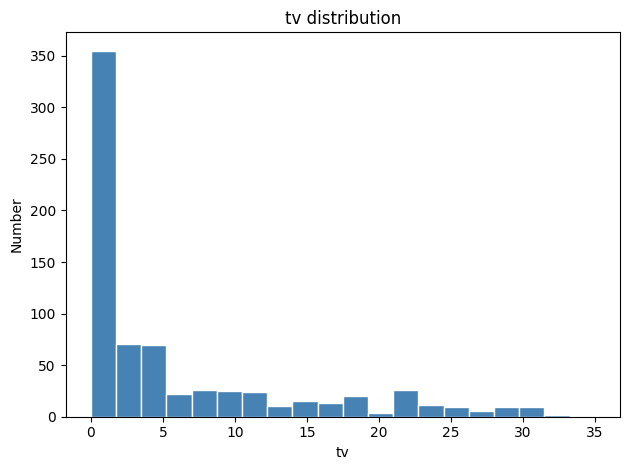

In [11]:
tv_data = pd.read_csv('data/input/nba/eda/haberstroh_team_ratings.csv', low_memory=False)
tv_data['tv_games'].dropna().plot(
    kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.title('tv distribution')
plt.xlabel('tv')
plt.ylabel('Number')
plt.tight_layout()
plt.show()

In [12]:
print(tv_data['tv_games'].value_counts(dropna=False))

tv_games
0     235
1     120
2      46
5      36
4      34
3      25
6      22
11     16
7      16
22     15
10     13
9      12
18     11
21     11
13     10
8      10
19      9
12      8
14      8
24      7
15      7
28      7
16      7
25      6
27      6
17      6
30      6
23      4
20      4
26      3
31      3
29      2
33      2
35      1
Name: count, dtype: int64


In [13]:
print(tv_data.groupby('szn_type')['tv_games'].describe())

                count       mean       std  min  25%  50%   75%   max
szn_type                                                             
all-star         10.0   0.800000  0.421637  0.0  1.0  1.0   1.0   1.0
play-in          34.0   1.235294  0.698866  0.0  1.0  1.0   2.0   2.0
playoffs        136.0   9.176471  6.390829  1.0  4.0  6.0  13.0  24.0
pre-season      276.0   0.355072  0.658381  0.0  0.0  0.0   1.0   3.0
regular season  270.0  10.703704  9.728335  0.0  2.0  7.0  19.0  35.0


In [14]:
nba_data = pd.read_csv('data/input/nba/tidy/L2M_stats_nba.csv', low_memory=False)

In [15]:
print(nba_data.head(10))
print()
print(nba_data.columns.tolist())

  period     time                       call_type        committing  \
0     Q4  01:52.0                  Foul: Shooting        Josh Smith   
1     Q4  01:43.0                  Foul: Shooting          JR Smith   
2     Q4  01:32.0                  Foul: Shooting      Trevor Ariza   
3     Q4  01:09.0                Foul: Loose Ball    Terrence Jones   
4     Q4  00:53.0                  Foul: Shooting  Tristan Thompson   
5     Q4  00:29.1                  Foul: Shooting    Terrence Jones   
6     Q5  04:34.0                  Foul: Shooting  Tristan Thompson   
7     Q5  04:34.0  Instant Replay: Support Ruling               NaN   
8     Q5  04:05.0                  Foul: Personal      LeBron James   
9     Q5  03:54.0           Foul: Double Personal      LeBron James   

      disadvantaged decision  \
0        Kevin Love      CNC   
1      James Harden       CC   
2      LeBron James       CC   
3  Tristan Thompson       CC   
4        Josh Smith      CNC   
5      LeBron James      C

The full list of variables is describe into README.md file in  **[AtlhawksfanaticL2M]**
- time remaining in the period when play occurred
- call_type: raw call type variable in L2M
- committing: committing player or team of the graded infraction in L2M, may be blank
- disadvantaged: disadvantaged player or team of the graded infraction in L2M, may be blank
- decision: judgment of L2M for the call, could be CC, CNC, IC, INC, or blank where CC = Correct Call, CNC = Correct Non-Call, IC = Incorrect Call, INC = Incorrect Non-Call and blank = ot detectable without technology
- comments: L2M comments on the play
- game_details: game details of L2M, only relevant for PDFs
- page: page of L2M for pdf, not applicable for games accessed through API
- file: name of L2M file, will be the saved .csv file for API data
- game_date: game date according to L2M report header
- away_team: away team nickname
- home_team: home team nickname
- date: date of game in YYYY-MM-DD format
- call: first part of call_type, this is before the colon in call_type
- type: second part of call_type, this is after the colon in call_type
- home: home team abbreviation
- away: away team abbreviation
- gid: NBA game ID
- gcode: NBA game code
- home_score: home final score from the L2M reports, incomplete variable
- away_score: away final score from the L2M reports, incomplete variable
- national_tv: national TV network for the game, “no” indicates none
- networks: shorthand TV network for the game, NBALP indicates league pass
- game_id: nba.com url for L2M game, last part of “https://official.nba.com/l2m/L2MReport.html/”, not applicable for PDFs
- PCTime: from official API
- ImposibleIndicator: from official API
- Difficulty: from official API
- VideolLink: from official API
- Qualifier: from official API
- posID: from official API
- posStart: from official API
- posEnd: from official API
- posTeamId: from official API
- teamIdInFavor: from official API
- errorInFavor: from official API
- imgChart: from official API
- GameId: from official API
- GameDate: from official API
- HomeTeamId: from official API
- AwayTeamId: from official API
- L2M_Comments: from official API
- season: NBA season for which the graded play was a part of, convention is to use the last year of the NBA season so 2015 refers to the 2014-15 Season
- playoff: dummy variable equal to TRUE if the game occurred in the playoffs
- GAME_ID: NBA API game ID, same as gid
- OFFICIAL_1: name of first referee for game
- OFFICIAL_2: name of second referee for game
- OFFICIAL_3: name of third referee for game
- OFFICIAL_ID_1: ID of first referee for game
- OFFICIAL_ID_2: ID of second referee for game
- OFFICIAL_ID_3: ID of third referee for game
- OFFICIAL_4: name of fourth referee for game, typically only for playoff games
- OFFICIAL_ID_4: ID of fourth referee for game, typically only for playoff games
- ATTENDANCE: attendance for the game
- committing_min: total minutes played by player committing action (note, may be NA because the player did not play and likely an input error from NBA on L2M)
- committing_team: team for committing player
- committing_side: home/away for committing player
- disadvantaged_min: total minutes played by player disadvantaged by action
- disadvantaged_team: team for disadvantaged player
- disadvantaged_side: home/away for disadvantaged player
- type2: consistent format for type of infraction
- time_min: minutes remaining in period
- time_sec: seconds remaining in period
- time2: fractional minutes left (ie 1.9 would be one minute and 54 seconds)

This analysis relies on thirteen columns from the dataset. The core variables are `decision`, `committing_side`, and `disadvantaged_side` — together they tell us whether a referee error favored the home or away team. `ATTENDANCE` serves as a proxy for crowd pressure. `OFFICIAL_1`, `OFFICIAL_2`, and `OFFICIAL_3` identify the referee crew — since individual decisions cannot be attributed to a specific referee, they are used to control for referee quality via `haberstroh_ref_ratings`. `season` and `playoff` provide temporal and competitive context. `gid`, `period`, `time_min`, and `call_type` are used for filtering and grouping.

In [16]:
pd.set_option('display.max_colwidth', None)
print(nba_data['comments'].head(10))
pd.reset_option('display.max_colwidth')

0                                                     Smith (HOU) does not make contact with Love (CLE) as he attempts the layup.
1                     Smith (CLE) makes contact with the body of Harden (HOU) and the contact affects his movement to the basket.
2                          Ariza (HOU) makes contact with the shoulder of James (CLE) while trying to strip the ball from behind.
3                            Jones (HOU) makes contact with the arm of Thompson (CLE) causing him to lose control of the rebound.
4                                                             Smith (HOU) loses the ball as he goes up for the shot in the paint.
5                                                                      Jones (HOU) maintains verticality on drive by James (CLE).
6                                           Thompson (CLE) makes contact to the head of Jones (HOU) from behind on the jump shot.
7        After communicating with the Replay Center, the foul was confirmed to have taken 

**Shape** — we check the number of rows and columns to confirm the dataset loaded correctly and matches the expected size from the source.

In [17]:
# Shape
print('Shape:', nba_data.shape)

Shape: (90302, 64)


The dataset contains 90,302 rows and 64 columns. Each row represents a single graded play — either a call made by referees or a potential violation that was not called. 

**Key columns** — out of 64 columns we focus on the subset relevant to our analysis:

- `decision` — the core variable: CC, CNC, IC, INC, or blank
- `committing_side` — whether the committing player is on the home or away team
- `disadvantaged_side` — whether the disadvantaged player is on the home or away team
- `season` — NBA season (convention: 2015 = 2014-15 season)
- `playoff` — True if the game was a playoff game
- `ATTENDANCE` — game attendance, used as a proxy for crowd pressure
- `OFFICIAL_1`, `OFFICIAL_2`, `OFFICIAL_3` — the three referees for the game
- `call_type` — type of violation or call
- `period` — game period (Q4, Q5 for overtime)
- `time` — time remaining in the period

**Data types** — we inspect the type of each column to identify parsing issues. Dates stored as strings or booleans stored as objects will need conversion before analysis.

In [18]:
key_cols = ['date', 'playoff', 'season', 'ATTENDANCE', 'decision', 
            'committing_side', 'disadvantaged_side', 'call_type',
            'period', 'time', 'OFFICIAL_1', 'OFFICIAL_2', 'OFFICIAL_3']
print(nba_data[key_cols].head())
print(nba_data[key_cols].dtypes)

         date  playoff  season  ATTENDANCE decision committing_side  \
0  2015-03-01    False    2015     18345.0      CNC            home   
1  2015-03-01    False    2015     18345.0       CC            away   
2  2015-03-01    False    2015     18345.0       CC            home   
3  2015-03-01    False    2015     18345.0       CC            home   
4  2015-03-01    False    2015     18345.0      CNC            away   

  disadvantaged_side         call_type period     time    OFFICIAL_1  \
0               away    Foul: Shooting     Q4  01:52.0  Dan Crawford   
1               home    Foul: Shooting     Q4  01:43.0  Dan Crawford   
2               away    Foul: Shooting     Q4  01:32.0  Dan Crawford   
3               away  Foul: Loose Ball     Q4  01:09.0  Dan Crawford   
4               home    Foul: Shooting     Q4  00:53.0  Dan Crawford   

      OFFICIAL_2  OFFICIAL_3  
0  Michael Smith  Tony Brown  
1  Michael Smith  Tony Brown  
2  Michael Smith  Tony Brown  
3  Michael Smith

> **Observation** — `date` is stored as object (string) and needs conversion to datetime. All other key columns have correct types. `playoff` is bool, `season` and `ATTENDANCE` are numeric. Categorical columns (`decision`, `committing_side`, `disadvantaged_side`, `call_type`, `period`) are object — expected for string categories. Conversion of `date` will be done in Tidy.

**Missing values** — we identify columns with missing data early. Some are expected — for example, `committing_min` is missing where the NBA made input errors. Others may signal structural issues in the data.

In [19]:
# Missing values
print('\nMissing values:')
print(nba_data.isnull().sum()[nba_data.isnull().sum() > 0])


Missing values:
call_type                48
committing             1522
disadvantaged          4983
decision               2502
comments                 59
game_details          58270
page                  58270
call                     48
type                     48
networks              88993
game_id               32032
PCTime                32032
ImposibleIndicator    32032
Difficulty            34148
VideolLink            32032
Qualifier             90302
posID                 32032
posStart              32032
posEnd                32032
posTeamId             32032
teamIdInFavor         90302
errorInFavor          90302
imgChart              32032
GameId                32032
GameDate              32032
HomeTeamId            32032
AwayTeamId            32032
L2M_Comments          89809
GAME_ID                 631
OFFICIAL_1              631
OFFICIAL_2              631
OFFICIAL_3              643
OFFICIAL_ID_1           631
OFFICIAL_ID_2           631
OFFICIAL_ID_3           643
OFF

Missing values аре three categories:

Expected and structural:
- `game_details`, `page` — 58,270 missing. These come from the PDF pipeline and are absent for all API-sourced games.
- `networks`, `L2M_Comments`, `Qualifier`, `teamIdInFavor`, `errorInFavor` — largely or entirely missing. Not used in our analysis.
- `OFFICIAL_4`, `OFFICIAL_ID_4` — 88,203 missing. A fourth referee appears only in some playoff games.

Require attention:
- `decision` — 2,502 missing. These are blank entries — plays not detectable without technology. Excluded from analysis.
- `committing_side`, `disadvantaged_side` — 2,433 and 5,801 missing. Critical for home/away bias calculation. Will be examined in Tidy.
- `OFFICIAL_1/2/3` — 631–643 missing. Games without referee data cannot be included in referee crew analysis.
- `ATTENDANCE` — 6,509 missing. Affects crowd pressure analysis.

Known data quality issue:
- `committing_min` — 3,183 missing. NBA input errors where the player did not actually play, documented in `no_minutes.csv` [AtlhawksfanaticL2M].

> **Observation** — missing values fall into three categories: structural (expected from the two-source pipeline), known data quality issues (documented in `no_minutes.csv`), and gaps in key analysis columns (`decision`, `committing_side`, `OFFICIAL_1/2/3`) that will be quantified in Tidy. 

**Dublication values** -we check whether the dataset contains any exact duplicate rows.

In [20]:
print('Duplicate rows:', nba_data.duplicated().sum())

Duplicate rows: 13


13 duplicate rows found — each is an exact copy of another row.
We inspect which games and decisions are affected.

In [21]:
print(nba_data[nba_data.duplicated(keep=False)][['season', 'home_team', 'away_team', 'date', 'decision', 'call_type', 'ATTENDANCE']].sort_values('date'))

       season  home_team      away_team        date decision  \
3392     2016      Bucks  Trail Blazers  2015-12-07      INC   
3393     2016      Bucks  Trail Blazers  2015-12-07      INC   
3414     2016       Heat        Wizards  2015-12-07       CC   
3415     2016       Heat        Wizards  2015-12-07       CC   
7730     2016      Hawks      Cavaliers  2016-04-01       CC   
7731     2016      Hawks      Cavaliers  2016-04-01       CC   
10711    2017      Bucks          Hawks  2016-12-09      CNC   
10712    2017      Bucks          Hawks  2016-12-09      CNC   
10913    2017      Bulls   Timberwolves  2016-12-13       CC   
10914    2017      Bulls   Timberwolves  2016-12-13       CC   
13548    2017      Bulls        Raptors  2017-02-14       CC   
13549    2017      Bulls        Raptors  2017-02-14       CC   
35552    2019  Grizzlies          Magic  2019-03-10       CC   
35551    2019  Grizzlies          Magic  2019-03-10       CC   
49663    2021   Warriors           Heat 

In [22]:
dupes = nba_data[nba_data.duplicated(keep=False)]
print('Total duplicate rows:', len(dupes))
print('Rows where all columns are identical to another row:')
print(nba_data.duplicated(keep='first').sum())

Total duplicate rows: 26
Rows where all columns are identical to another row:
13


26 rows are shown because `keep=False` marks both the original and the copy. Each pair represents one duplicate — 13 pairs total.

We check how many unique games are affected.

In [23]:
print(nba_data[nba_data.duplicated(keep=False)]['gid'].unique())

[21500310 21500306 21501131 21600340 21600370 21600831 21800996 22000443
 22000459 22100105 22100852 22400587 22400931]


In [24]:
13 unique games — one duplicated row per game, spanning seasons 2016–2025.

SyntaxError: invalid character '—' (U+2014) (2085155020.py, line 1)

In [ ]:
mask = nba_data.duplicated(keep=False)
print(nba_data[mask][nba_data[mask]['date'] == '2022-02-12'][['gid', 'home_team', 'away_team', 'date', 'ATTENDANCE']].drop_duplicates(subset='gid'))

The duplicate on `2022-02-12` belongs to Bulls vs Thunder (gid=22100852).

> **Observation** — the dataset contains 13 duplicate rows. `duplicated(keep='first')` returns 13 — the number of rows to be removed. `duplicated(keep=False)` returns 26 — both the original and the copy in each pair. The duplicates span 13 different games across seasons 2016–2025, confirmed by 13 unique `gid` values. Each game has exactly one duplicated row — a double entry from the parsing pipeline. The date `2022-02-12` in the duplicates belongs to Bulls vs Thunder (gid=22100852). All 13 duplicate rows will be removed in Tidy.

##### **COLUMN-LEVEL ANALYSIS**  
- **Decision column** — the core variable of the analysis. We examine the distribution of values to understand the balance between correct and incorrect calls, and to confirm the presence of blank entries that will be excluded.  CC (Correct Call), CNC (Correct Non-Call), IC (Incorrect Call), and INC (Incorrect Non-Call)

In [ ]:
print(nba_data['decision'].value_counts(dropna=False))

The key variable is `decision`, which takes four values: **CC** (Correct Call), **CN**C (Correct Non-Call), **IC** (Incorrect Call), and **INC** (Incorrect Non-Call). A fifth value — blank — indicates plays that were not detectable without technology and are excluded from analysis.

In [ ]:
nba_data['decision'].value_counts(dropna=False).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision distribution')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

> **Observation** — CNC dominates with 60,590 entries (67%), confirming that the majority of graded plays are correct non-calls. The inconsistency in CNC criteria across seasons — documented in [AtlhawksfanaticL2M] and visible in the EDA — justifies their exclusion. NaN (2,502) represents plays not detectable without technology and is also excluded. The working dataset consists of CC (21,023), IC (796), and INC (5,391) — a total of 27,210 rows.

- **Season column** — we check the distribution of rows by season to confirm coverage and identify any gaps.

We count the number of rows per season to confirm coverage and identify gaps.

In [ ]:
# Games per season
print(nba_data.groupby('season')['gid'].nunique())

2018 has more games (475) than 2019 (455), yet 2019 has more rows. This means the difference is not in the number of games — we check average actions per game to find the cause.

**Note** — the dataset contains 395–475 games per season, not 1,230. L2M reports are released only for close games (≤5 points in the last two minutes), which represents approximately 35–40% of all regular season games. A standard NBA season has 1,230 games (30 teams × 82 games / 2) [AtlhawksfanaticL2M].

In [ ]:
# Rows per game by season
print(nba_data.groupby('season').apply(
    lambda x: len(x) / x['gid'].nunique(), include_groups=False
).round(1))

2019 peaks at 25.1 actions per game — the highest in the dataset. This confirms that 2019 has more rows than 2018 despite fewer games because referees reviewed more actions per game. The drop in 2020–2022 reflects both fewer games (395–406 vs 455–475) and fewer actions per game (19.5–20.8 vs 25.1).

**Note** — A standard NBA season has 1,230 games (30 teams × 82 games / 2) [FansidedNBA]

In [ ]:
nba_data.groupby('season')['gid'].nunique().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Games by season')
plt.xlabel('Season')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

> **Observation** — 2015 has significantly fewer rows (1,972) and fewer games (139) as it was the first year of L2M reporting. Coverage stabilizes from 2016 onward. The drop in 2020–2022 reflects both fewer games (395–442 vs 455–475 in 2018–2019) and fewer graded actions per game (19.5–20.8 vs 25.1 in 2019). 2025 shows the lowest actions per game (16.9) because the season was still ongoing when the data was collected.

- **Playoff column** — We check the split between regular season and playoff games.

In [ ]:
print('Unique values:')
print(nba_data['playoff'].unique())
print()
print('Missing:', nba_data['playoff'].isnull().sum())
print()
print(nba_data['playoff'].value_counts())

> **Observation** — no missing values. Two clean boolean values. 6,581 rows (7.3%) are playoff games. Playoff games will be analyzed separately as [PelechrinisL2M] found home court bias to be more pronounced in the playoffs.

- **Committing side** - `committing_side` — identifies whether the player committing the infraction belongs to the home or away team. Together with `decision`, this is the core column for calculating home/away bias. A systematic imbalance — where home teams commit more unpenalized infractions — would indicate referee bias in favor of the home team.

In [ ]:
print('Unique values:')
print(nba_data['committing_side'].unique())
print()
print('Missing:', nba_data['committing_side'].isnull().sum())
print()
print(nba_data['committing_side'].value_counts(dropna=False))

> **Observation** — two clean values: home and away, nearly balanced (44,183 away vs 43,686 home). 2,433 missing (2.7%). The balance is expected — there is no reason for one side to commit more infractions by default. Missing values will be examined in Tidy.

- **Disadvantaged side** -`disadvantaged_side` — identifies whether the player disadvantaged by the infraction belongs to the home or away team. Used together with `committing_side` and `decision` to determine the direction of benefit from each error.

In [ ]:
print('Unique values:')
print(nba_data['disadvantaged_side'].unique())
print()
print('Missing:', nba_data['disadvantaged_side'].isnull().sum())
print()
print(nba_data['disadvantaged_side'].value_counts(dropna=False))

> **Observation** — two clean values: home and away, nearly balanced (42,428 home vs 42,073 away). 5,801 missing (6.4%) — notably more than `committing_side` (2,433). This is expected as some plays have a committing player but no clearly identified disadvantaged player. Missing values will be examined in Tidy.

**Attendance field** `ATTENDANCE` — used as a proxy for crowd pressure. We check the range and distribution of values, including games with zero attendance which correspond to the COVID bubble.

Unique values and missing — we check the range of attendance values and identify missing entries.

In [ ]:
print('Unique values:')
print(nba_data['ATTENDANCE'].unique())
print()
print('Missing:', nba_data['ATTENDANCE'].isnull().sum())
print()
print(nba_data['ATTENDANCE'].value_counts(dropna=False))

Distribution plot — we visualize the attendance distribution to identify patterns and anomalies.

In [ ]:
nba_data.drop_duplicates(subset='gid')['ATTENDANCE'].dropna().plot(
    kind='hist', bins='fd', color='steelblue', edgecolor='white')
plt.title('Attendance distribution (per game)')
plt.xlabel('Attendance')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

Low attendance investigation — the histogram shows a small group below 5,000. We identify which seasons these belong to.

In [ ]:
print('Rows with ATTENDANCE < 5000:')
print(nba_data[nba_data['ATTENDANCE'] < 5000]['season'].value_counts().sort_index())

**Unexpected finding** — zero attendance appears only in 2022, not in 2020 as expected from the COVID bubble. We investigate which games these are. 2022 low attendance

In [ ]:
mask = (nba_data['ATTENDANCE'] < 5000) & (nba_data['season'] == 2022)
cols = ['gid', 'season', 'home_team', 'away_team', 'date', 'call_type', 'decision', 'ATTENDANCE']
print(f'Rows: {mask.sum()}, Unique games: {nba_data[mask]["gid"].nunique()}')
print(nba_data[mask][cols].to_string())

We confirm the single 2022 game with restricted attendance and verify that 13 rows correspond to one game.

In [ ]:
games = nba_data.drop_duplicates(subset='gid')
print(games.groupby('home_team')['ATTENDANCE'].median().sort_values(ascending=False).head(15))

Тhe peaks in the attendance distribution reflect fixed arena capacities. Bulls lead with median 21,116, followed by 76ers (20,319) and Mavericks (20,157). This is expected — arenas have a maximum capacity which creates natural clustering. This does not affect our analysis.

> **Observation** — attendance shows a bimodal distribution. The main group clusters between 13,000–23,000 (normal games). A second group of 2,877 rows falls below 5,000 — 2,864 from the 2021 season played with restricted crowd capacity, and 13 rows from the Raptors vs Nuggets game (February 12, 2022). When analyzing the correlation between attendance and referee bias, these two groups must be treated separately or controlled for via `season`.

**Referee columns** — each game has up to three referees recorded in `OFFICIAL_1`, `OFFICIAL_2`, `OFFICIAL_3`. A fourth referee appears only in some playoff games.

In [ ]:
print('Missing referee data:')
print('OFFICIAL_1:', nba_data['OFFICIAL_1'].isnull().sum())
print('OFFICIAL_2:', nba_data['OFFICIAL_2'].isnull().sum())
print('OFFICIAL_3:', nba_data['OFFICIAL_3'].isnull().sum())
print('OFFICIAL_4:', nba_data['OFFICIAL_4'].isnull().sum())
print()
print('Unique referees (OFFICIAL_1):', nba_data['OFFICIAL_1'].nunique())
print('Unique referees (OFFICIAL_2):', nba_data['OFFICIAL_2'].nunique())
print('Unique referees (OFFICIAL_3):', nba_data['OFFICIAL_3'].nunique())
print('Unique referees:', pd.concat([
    nba_data['OFFICIAL_1'], 
    nba_data['OFFICIAL_2'], 
    nba_data['OFFICIAL_3']
]).nunique())

**Unexpected** — 88,203 missing values for `OFFICIAL_4` seems high. We verify whether the fourth referee appears exclusively in playoff games.

In [ ]:
print(nba_data[nba_data['OFFICIAL_4'].notna()]['playoff'].value_counts())

- 2,021 out of 2,099 rows with a fourth referee are playoff games, as expected. The remaining 78 regular-season games with a fourth referee are likely special cases. This confirms that `OFFICIAL_4` missingness is structural and not a data quality issue.

- 109 unique referees across all three positions. The variation between positions (100, 104, 89) suggests that referee assignment to position 1/2/3 is not consistent. This is confirmed by the pivot table — every referee appears across multiple positions. This is why we combine all three columns when counting unique referees.

In [ ]:
officials_pivot = pd.DataFrame({
    'in_pos_1': nba_data.groupby('OFFICIAL_1').size(),
    'in_pos_2': nba_data.groupby('OFFICIAL_2').size(),
    'in_pos_3': nba_data.groupby('OFFICIAL_3').size()
}).fillna(0).astype(int)

print(officials_pivot[officials_pivot.gt(0).sum(axis=1) > 1].head(10))

> **Observation** — referee data is missing for 631–643 rows, representing games where referee identity was not recorded. These rows will be excluded from referee crew analysis. There are 109 unique referees across all three positions. Most referees appear across multiple positions — confirmed by the pivot table. This means the three columns must always be treated together — never individually — when identifying referee participation in a game. `OFFICIAL_4` is missing for 88,203 rows — as expected, a fourth referee appears only in some playoff games.

**Call type** — we check the distribution of violation types to understand what kinds of plays are graded in the L2M reports.

In [ ]:
print(nba_data['call_type'].value_counts().head(10))

> **Observation** — foul calls dominate the dataset. Personal fouls (27,223) and shooting fouls (23,121) together account for more than half of all graded plays. This matters for our analysis — fouls are subjective calls where referee discretion is highest, making them the most likely category to show systematic bias.

**Period and time** — we check which periods are covered and the time range within each period.

In [ ]:
print('Period distribution:')
print(nba_data['period'].value_counts())

> **Observation** — the majority of graded plays occur in Q4 (78,374). Overtime periods Q5 through Q8 account for 11,928 rows (13.2%). Overtime games are included in the analysis as they represent close games where crowd pressure and referee bias are equally relevant.

**Time remaining** — we check the range of time values within periods.

In [ ]:
print(nba_data['time_min'].describe())

`time_min` max of 12 is unexpected. L2M reports should only cover the last two minutes of each period. We investigate these rows.

In [ ]:
print(nba_data[nba_data['time_min'] > 2][['period', 'time', 'time_min', 'season', 'decision']].head(10))

Rows with `time_min > 2` are exclusively from Q5 (overtime) in the 2015 season. In overtime, the full 5-minute period was graded, not just the last 2 minutes. This is a known inconsistency in early L2M reporting. These rows are outside the standard 2-minute window but will be retained — excluding them would disproportionately affect 2015 data, which is already the smallest season.

> **Observation** — most graded plays occur in the final minute of the period (median = 0, Q3 = 1). The max of 12 minutes is an anomaly that will be examined in Tidy.

**Supporting files** — we load and briefly inspect the three additional files.

`haberstroh_ref_ratings.csv` — referee quality ratings by season and game type.  
`haberstroh_team_ratings.csv` — team ratings by season and game type.  
`no_minutes.csv` — rows where `committing_min` is missing due to NBA input errors. Used in Tidy to document the exclusion decision.

In [ ]:
ref_ratings = pd.read_csv('data/input/nba/eda/haberstroh_ref_ratings.csv')
print('Shape:', ref_ratings.shape)
print(ref_ratings.head())

In [ ]:
team_ratings = pd.read_csv('data/input/nba/eda/haberstroh_team_ratings.csv')
print('Shape:', team_ratings.shape)
print(team_ratings.head())

In [ ]:
no_minutes = pd.read_csv('data/input/nba/eda/no_minutes.csv')
print('Shape:', no_minutes.shape)
print(no_minutes.head())

> **Observation** — all three files loaded correctly.  
> `haberstroh_ref_ratings.csv` covers seasons 2016–2025 with `ref_rating` calculated as `ref_points / games`.
>  A lower rating indicates more errors per game.  
> `haberstroh_team_ratings.csv` covers the same period with team-level ratings based on the quality of referee crews assigned to their games.  
> `no_minutes.csv` has 50 columns — it is a full copy of the main dataset filtered to rows with missing `committing_min`. All 40 rows are CNC decisions, suggesting these are plays where no player was formally identified as committing a violation.

#### b Exploratory Data Analysis (EDA)

**Decision distribution by season** — in IDA we noted that CNC criteria are inconsistent across seasons. Here we visualize this directly to confirm the exclusion is justified.  
**CNC trend by season** — a line plot to clearly show the growth of CNC entries over time, which justifies their exclusion from analysis.

In [ ]:
cnc_pct = dec_by_season_pct['CNC']

plt.figure(figsize=(10, 4))
plt.plot(cnc_pct.index.astype(str), cnc_pct.values, marker='o', linewidth=2, color='#FF9800')
plt.title('CNC % by season')
plt.xlabel('Season')
plt.ylabel('% of all decisions')
plt.tight_layout()
plt.show()

**Working dataset distribution by season** — CC, IC, INC only, excluding CNC and blank entries.

In [ ]:
errors_by_season = nba_data[nba_data['decision'].isin(['IC', 'INC'])].groupby('season').size()

plt.figure(figsize=(10, 4))
plt.bar(errors_by_season.index.astype(str), errors_by_season.values, color='steelblue', edgecolor='white')
plt.title('Number of errors (IC + INC) by season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.style.use('seaborn-v0_8-whitegrid')
plt.tight_layout()
plt.show()

**Observation** — absolute error count is affected by the number of games per season. 2015 has fewer errors simply because it has fewer games. 2016 peaks at ~750 errors. COVID seasons (2020–2021) show a drop consistent with fewer games played. 2025 is incomplete — the season was still ongoing when the data was collected.

The raw count is not directly comparable across seasons without normalizing by number of games. This will be addressed in the next plot.

**Error rate by season** — errors per game, to make seasons directly comparable.

In [ ]:
errors_per_game = nba_data[nba_data['decision'].isin(['IC', 'INC'])].groupby('gid').size()

plt.figure(figsize=(10, 4))
plt.hist(errors_per_game.values, bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of errors per game')
plt.xlabel('Number of errors per game')
plt.ylabel('Number of games')
plt.tight_layout()
plt.show()

## Reference

[PelechrinisL2M] Pelechrinis, K. (2023). Quantifying implicit biases in refereeing using NBA referees as a testbed. *Scientific Reports*, 13, 4664. https://doi.org/10.1038/s41598-023-31799-y  
[PelechrinisCode] Pelechrinis, K. (2023). NBA-ref-analysis. GitHub. https://github.com/kpelechrinis/NBA-ref-analysis  
[AtlhawksfanaticL2M] atlhawksfanatic. (2025). L2M: NBA Last Two Minute Reports. GitHub. https://github.com/atlhawksfanatic/L2M  
[FansidedNBA] FanSided. (2024). How many games are in the NBA season? https://fansided.com/posts/how-many-games-are-in-the-nba-season-01j8kcxt31rr  
[ErikstadJohansen2020] Erikstad, M. K., & Johansen, B. T. (2020). Referee bias in professional football: Favoritism toward successful teams in potential penalty situations. Frontiers in Sports and Active Living, 2, 19. https://doi.org/10.3389/fspor.2020.00019  
[Barrett2021] Barrett, D. (2021). Star player bias in the NBA: A quantile regression approach. Empirical Economics Bulletin, 14(1), 9. 
[Rothman1990] Rothman, K. J. (1990). No adjustments are needed for multiple  comparisons. Epidemiology, 1(1), 43–46. https://doi.org/10.1097/00001648-199001000-00010


